# RAG 파이프라인 (Retrieval-Augmented Generation)

세 가지 공정 지식 소스를 벡터 DB에 저장하고, EXAONE LLM으로 질의응답을 수행하는 파이프라인입니다.

**파이프라인 순서:**
1. 문서 로드 (논문 rule JSON + OPLS 공정 JSON + SHAP 분석 Markdown)
2. 청크 분할 → 임베딩 (multilingual-e5-large-instruct) → Chroma DB 저장
3. LLM 로드 (EXAONE-3.5-7.8B-Instruct, 4bit 양자화)
4. RAG Chain 구성 및 질의응답

**필요 파일:**
- `../data/rag_data_all.json` — 논문 기반 공정 rule
- `../data/opls_process_knowledge.json` — 현업 OPLS 공정 조치 정보
- `../data/shap_analysis_for_rag.md` — SHAP 기반 모델 해석 정보

## 0. 환경 설정

In [1]:
import glob, os, re

files = glob.glob(os.path.expanduser(
    "~/.cache/huggingface/modules/transformers_modules/**/*.py"
), recursive=True)
target = [f for f in files if "modeling_exaone" in f]

for path in target:
    txt = open(path).read()
    # 망가진 create_causal_mask 호출 전체를 올바른 버전으로 교체
    patched = re.sub(
        r'causal_mask = create_causal_mask\(.*?\)',
        (
            "causal_mask = create_causal_mask(\n"
            "            config=self.config,\n"
            "            inputs_embeds=inputs_embeds,\n"
            "            attention_mask=attention_mask,\n"
            "            past_key_values=past_key_values,\n"
            "            position_ids=position_ids,\n"
            "        )"
        ),
        txt,
        flags=re.DOTALL
    )
    if patched != txt:
        open(path, "w").write(patched)
        print(f"패치 완료: {path}")
    else:
        print(f"변경 없음: {path}")


변경 없음: /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py


In [2]:
#1. Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

#2. Github에서 코드 가져오기
!git clone https://github.com/heyitsmialee/PRAGma.git
%cd PRAGma

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'PRAGma' already exists and is not an empty directory.
/content/PRAGma


In [3]:
import subprocess, sys, os

PACKAGES = [
    "langchain", "langchain-core", "langchain-community",
    "langchain-text-splitters", "langchain-huggingface",
    "langchain-chroma", "langchain-google-genai",
    "sentence-transformers", "ragas>=0.2.0", "datasets",
    "rank_bm25",
    "langchain-google-vertexai",
]

print("패키지 설치 중...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U"] + PACKAGES, check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers>=4.52.0", "accelerate", "bitsandbytes", "torch"], check=True)
print("설치 완료.")

# 설치 후 import 확인 — 실패 시 자동 런타임 재시작
try:
    import importlib
    importlib.import_module("langchain_huggingface")
    print("패키지 정상 — 재시작 불필요, 다음 셀로 진행합니다.")
except Exception as e:
    print(f"런타임 재시작 필요 ({e})")
    print("재시작 후 자동으로 '모두 실행'을 다시 누르거나 Ctrl+F9를 눌러주세요.")
    os.kill(os.getpid(), 9)

패키지 설치 중...
설치 완료.
패키지 정상 — 재시작 불필요, 다음 셀로 진행합니다.


In [4]:
# API 키 / 토큰 설정
# Colab 왼쪽 사이드바 → 🔑 Secrets 에서 HF_TOKEN, GEMINI_KEY 를 추가하세요.
# (GitHub에 절대 직접 입력하지 마세요)

from google.colab import userdata

HF_TOKEN   = userdata.get("HF_TOKEN")
GEMINI_KEY = userdata.get("GEMINI_KEY")

if not HF_TOKEN:
    raise ValueError("Secrets에 HF_TOKEN이 없습니다. 왼쪽 🔑 아이콘 → Add new secret 으로 추가하세요.")
if not GEMINI_KEY:
    raise ValueError("Secrets에 GEMINI_KEY가 없습니다. 왼쪽 🔑 아이콘 → Add new secret 으로 추가하세요.")

print("토큰 로드 완료")

토큰 로드 완료


In [5]:
# Google Gemini API 키 설정 (RAGAS judge 모델용)
import os
os.environ["GOOGLE_API_KEY"] = GEMINI_KEY

## 1. 문서 로드 함수

세 가지 소스를 각각 로드합니다.

- `load_json_as_documents`: JSON 항목 전체를 문자열로 변환하여 `Document` 생성, `type` 메타데이터 부여
- `load_markdown_as_documents`: TextLoader로 Markdown 파일 로드, `type=shap_analysis` 메타데이터 부여

In [6]:
# EXAONE modeling_exaone.py가 구버전 API로 create_causal_mask를 호출하는 문제 패치
import transformers.modeling_utils as _tmu

if hasattr(_tmu, 'create_causal_mask'):
    _orig = _tmu.create_causal_mask
    def _patched(*args, **kwargs):
        kwargs.pop('input_embeds', None)
        return _orig(*args, **kwargs)
    _tmu.create_causal_mask = _patched

In [7]:
import os
import json
from typing import List

import torch

from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma

from transformers import BitsAndBytesConfig
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


def load_json_as_documents(json_path: str, knowledge_type: str) -> List[Document]:
    documents = []

    if not os.path.exists(json_path):
        print(f"JSON 파일 없음: {json_path}")
        return documents

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        content = json.dumps(item, ensure_ascii=False, indent=2)

        documents.append(
            Document(
                page_content=content,
                metadata={
                    "source": json_path,
                    "type": knowledge_type,
                    "id": item.get("paper_id", item.get("opls_id", ""))
                }
            )
        )

    return documents


def load_markdown_as_documents(md_path: str) -> List[Document]:
    if not os.path.exists(md_path):
        print(f"Markdown 파일 없음: {md_path}")
        return []

    loader = TextLoader(file_path=md_path, encoding="utf-8")
    docs = loader.load()

    for doc in docs:
        doc.metadata["source"] = md_path
        doc.metadata["type"] = "shap_analysis"

    return docs

/tmp/ipykernel_4607/521328349.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


## 2. RAG 파이프라인 설정 함수

- **문서 로드**: `rag_data_all.json` (논문 rule) + `opls_process_knowledge.json` (OPLS 공정) + `shap_analysis_for_rag.md` (SHAP 분석)
- **청크 분할**: `chunk_size=700`, `chunk_overlap=100`
- **임베딩 모델**: `intfloat/multilingual-e5-large-instruct`
- **벡터 DB**: Chroma (`chroma_rag_data` 컬렉션), `rebuild_db=True`면 재구성 / `False`면 기존 DB 재사용
- **LLM**: `LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct` (4bit 양자화)
- **Retriever**: 상위 `k=3` 청크 검색
- **프롬프트**: 핵심 답변 · 관련 공정 변수 · 근거 · 공정 조정 방향 포맷

In [15]:
from huggingface_hub import login
login(token=HF_TOKEN)

if '_embedding_model' not in globals():
    _embedding_model = None
if '_chat_llm' not in globals():
    _chat_llm = None


def load_models(force_reload=False):
    global _embedding_model, _chat_llm

    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA GPU를 찾을 수 없습니다.\n"
            "Runtime > Change runtime type > Hardware accelerator > GPU 로 변경 후 재실행하세요."
        )

    if _embedding_model is None or force_reload:
        print("임베딩 모델 로드 중...")
        _embedding_model = HuggingFaceEmbeddings(
            model_name="intfloat/multilingual-e5-large-instruct",
            encode_kwargs={"normalize_embeddings": True},
        )
        print("임베딩 모델 로드 완료")
    else:
        print("[캐시] 임베딩 모델 재사용")

    if _chat_llm is None or force_reload:
        print("EXAONE LLM 로드 중... (최초 1회, 수십 분 소요)")
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        chat_model = HuggingFacePipeline.from_model_id(
            model_id="LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct",
            task="text-generation",
            pipeline_kwargs={
                "max_new_tokens": 512,
                "do_sample": False,
                "repetition_penalty": 1.03,
                "max_length": None,
            },
            model_kwargs={
                "quantization_config": quantization_config,
                "trust_remote_code": True
            }
        )
        _chat_llm = ChatHuggingFace(llm=chat_model)
        print("LLM 로드 완료")
    else:
        print("[캐시] LLM 재사용")

    return _embedding_model, _chat_llm


E5_PREFIX = "Instruct: 공정 이상 원인과 조치 방법을 찾으세요\nQuery: "


def build_rag_chain(
    embedding_model,
    llm,
    paper_json_path="/content/PRAGma/data/rag_data_all.json",
    opls_json_path="/content/PRAGma/data/opls_process_knowledge.json",
    shap_md_path="/content/PRAGma/notebooks/shap_analysis_for_rag.md",
    db_dir="./chroma_huggingface",
    rebuild_db=True
):
    from langchain_community.retrievers import BM25Retriever
    from langchain_core.retrievers import BaseRetriever
    from langchain_core.runnables import RunnableLambda
    from langchain_core.callbacks import CallbackManagerForRetrieverRun
    from typing import List as _List

    print("1. 문서 로드 중...")
    document_list = []
    document_list.extend(load_json_as_documents(paper_json_path, "paper_rule"))
    document_list.extend(load_json_as_documents(opls_json_path, "opls_process_rule"))
    document_list.extend(load_markdown_as_documents(shap_md_path))

    if not document_list:
        print("로드된 문서가 없습니다.")
        return None, None, None

    print(f"로드된 문서 수: {len(document_list)}")

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=80)
    split_docs = text_splitter.split_documents(document_list)
    print(f"분할된 Chunk 수: {len(split_docs)}")

    print("2. Chroma DB 설정 중...")
    if rebuild_db:
        database = Chroma.from_documents(
            documents=split_docs,
            embedding=embedding_model,
            collection_name="chroma_rag_data",
            persist_directory=db_dir
        )
    else:
        database = Chroma(
            collection_name="chroma_rag_data",
            embedding_function=embedding_model,
            persist_directory=db_dir
        )

    vector_ret = database.as_retriever(search_kwargs={"k": 5})

    bm25_ret_inner = BM25Retriever.from_documents(split_docs)
    bm25_ret_inner.k = 5

    # EnsembleRetriever 대신 커스텀 Hybrid Retriever 구현
    # (최신 LangChain에서 EnsembleRetriever가 langchain/langchain_community 양쪽에서 제거됨)
    class HybridRetriever(BaseRetriever):
        def _get_relevant_documents(
            self, query: str, *, run_manager: CallbackManagerForRetrieverRun = None
        ) -> _List[Document]:
            vec_docs  = vector_ret.invoke(E5_PREFIX + query)
            bm25_docs = bm25_ret_inner.invoke(query)
            seen, combined = set(), []
            for doc in vec_docs + bm25_docs:
                key = doc.page_content[:80]
                if key not in seen:
                    seen.add(key)
                    combined.append(doc)
            return combined[:7]

        async def _aget_relevant_documents(
            self, query: str, *, run_manager=None
        ) -> _List[Document]:
            return self._get_relevant_documents(query)

    hybrid_retriever = HybridRetriever()

    template = """
다음 문맥을 참고하여 질문에 답변해 주세요.

문맥에는 논문 기반 공정 rule, 현업 OPLS 공정 조치 정보,
SHAP 기반 모델 해석 정보가 포함될 수 있습니다.

답변 시 아래 내용을 중심으로 정리해 주세요.
- 질문에 대한 핵심 답변
- 관련 공정 변수
- 모델 또는 문헌 기반 근거
- 필요 시 공정 조정 방향

문맥:
{context}

질문:
{question}

답변:
"""

    prompt = PromptTemplate.from_template(template)

    def format_docs(docs):
        lines = []
        for doc in docs:
            src = doc.metadata.get("source", "")
            typ = doc.metadata.get("type", "")
            lines.append(f"[source={src}, type={typ}]\n{doc.page_content}")
        return "\n\n".join(lines)

    rag_chain = (
        {"context": hybrid_retriever | format_docs,
         "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    print("RAG Chain 구성 완료 (Hybrid BM25+Vector / E5 prefix / k=5 / chunk=400)")
    return rag_chain, hybrid_retriever, split_docs

## 3. 질의응답 함수

`rag_chain.invoke(query)`로 질문 문자열을 직접 전달하고, 답변 문자열을 반환합니다.

In [16]:
def query_rag(rag_chain, query):
    if rag_chain is None:
        print("체인이 구성되지 않았습니다.")
        return None

    print(f"\n[질문]: {query}")

    answer = rag_chain.invoke(query)

    print("[답변]:\n")
    print(answer)

    return answer

## 4. 파이프라인 실행

두 단계로 나눠 실행합니다.

- **Step 1 — 모델 로드**: 최초 1회만 실행. 이미 로드된 경우 `[캐시]` 메시지 출력 후 즉시 반환.
- **Step 2 — RAG 체인 구성**: 모델을 재사용해 빠르게 재구성. 데이터나 파라미터를 바꿀 때 이 셀만 다시 실행하면 됩니다.

In [17]:
## 4b. Baseline 비교 체인 구성 함수 정의 (LLM only / BM25 RAG)
from langchain_community.retrievers import BM25Retriever

LLM_ONLY_TEMPLATE = """다음 질문에 답변해 주세요.

질문:
{question}

답변:
"""

BM25_RAG_TEMPLATE = """다음 문맥을 참고하여 질문에 답변해 주세요.

문맥:
{context}

질문:
{question}

답변:
"""

def _fmt(docs):
    return "\n\n".join(
        f"[source={d.metadata.get('source','')}, type={d.metadata.get('type','')}]\n{d.page_content}"
        for d in docs
    )

def build_llm_only_chain(llm):
    prompt = PromptTemplate.from_template(LLM_ONLY_TEMPLATE)
    return prompt | llm | StrOutputParser()

def build_bm25_chain(llm, docs):
    bm25_ret = BM25Retriever.from_documents(docs)
    bm25_ret.k = 3
    prompt = PromptTemplate.from_template(BM25_RAG_TEMPLATE)
    chain = (
        {"context": bm25_ret | _fmt, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    return chain, bm25_ret

# 실제 체인 구성은 split_docs가 만들어지는 Step 2(다음 셀) 이후에 실행됩니다.
print("Baseline 체인 함수 정의 완료")

Baseline 체인 함수 정의 완료


In [18]:
## 4c. Model RAG 체인 구성 함수 정의 (LightGBM 예측 + OPLS 컨텍스트 주입)
import pickle
import numpy as np
import pandas as pd

MODEL_RAG_TEMPLATE = """다음 문맥을 참고하여 질문에 답변해 주세요.

문맥에는 논문 기반 공정 rule, 현업 OPLS 공정 조치 정보,
SHAP 기반 모델 해석 정보 및 현재 LOT ML 예측 결과가 포함됩니다.

[현재 공정 실측 및 ML 예측 현황]
{lot_context}

[지식베이스 컨텍스트]
{knowledge_context}

답변 시 아래 내용을 중심으로 정리해 주세요.
- 현재 LOT 상태와 연계한 핵심 답변
- 관련 공정 변수
- 모델 또는 문헌 기반 근거
- 필요 시 공정 조정 방향

질문:
{question}

답변:
"""


def build_model_rag_chain(llm, retriever, lot_no: str = "A20000"):
    """LightGBM 예측 + OPLS 이탈 정보를 컨텍스트로 주입하는 RAG 체인

    Args:
        llm      : 이미 로드된 EXAONE LLM
        retriever: 기존 Hybrid retriever (Vector RAG 재사용)
        lot_no   : 평가에 사용할 대표 LOT 번호 (평가 전체에서 고정)

    Returns:
        (chain, lot_context_str) 튜플
    """
    from langchain_core.runnables import RunnableLambda

    # ── 경로 설정 (GitHub clone 우선, Drive fallback) ────────────────────────
    lgbm_path = "/content/PRAGma/notebooks/best_LightGBM_mass_speed_regressor.pkl"
    csv_path  = "/content/PRAGma/data/Train_0319.csv"
    if not os.path.exists(lgbm_path):
        lgbm_path = "/content/drive/MyDrive/Colab Notebooks/PRAGma/best_LightGBM_mass_speed_regressor.pkl"
    if not os.path.exists(csv_path):
        csv_path = "/content/drive/MyDrive/Colab Notebooks/PRAGma/Train_0319.csv"

    with open(lgbm_path, "rb") as f:
        _lgbm = pickle.load(f)
    _feats = _lgbm.feature_name_
    _df    = pd.read_csv(csv_path, encoding="cp949")

    # ── 피처 매핑 (인코딩 차이 자동 대응) ──────────────────────────────────
    _cont_map = {
        "Cu 표면두께 Max_Val"   : "cu_thick_max",
        "Cu 표면두께 AVG_VAL"   : "cu_thick_avg",
        "Cu 표면두께 Min_Val"   : "cu_thick_min",
        "Cu 표면두께 Std_Val"   : "cu_thick_std",
        "Cu 표면두께 Median_Val": "cu_thick_median",
    }
    _suffix_map = {
        "Etch factor"              : "etch_factor",
        "Etching(염화동) - Cu"    : "meas_etch_cu",
        "Etching(염화동) - HCl"   : "meas_etch_hcl",
        "Etching(염화동) - 비중"  : "meas_etch_sg",
        "Etching(염화동) - 온도"  : "meas_etch_temp",
        "Etching-첨가제(HB-120EF)": "meas_etch_additive",
        "Etching량"               : "meas_etch_amount",
        "Soft Etch - Cu"          : "meas_softetch_cu",
        "Soft Etch - H2SO4"       : "meas_softetch_h2so4",
        "Soft Etch - SPS"         : "meas_softetch_sps",
        "박리액 - 농도"           : "meas_strip_conc",
        "수세수 - pH"             : "meas_rinse_ph",
        "현상액 - pH"             : "meas_dev_ph",
        "현상액 - 농도"           : "meas_dev_conc",
    }
    for col in _df.columns:
        if "析치" in col or "분析치" in col or "분석치" in col:
            suffix = col.split("_", 1)[-1] if "_" in col else col
            if suffix in _suffix_map:
                _cont_map[col] = _suffix_map[suffix]

    _cat_cols = {
        "재작업사유"   : {"prefix": "rework_history", "values": ["Unknown","기타","기판 겹침","두께 미달","딤플","설비 에러"], "sep": "_"},
        "노광 설비정보": {"prefix": "expo_eq_id",     "values": [f"EXP-{i:03d}" for i in range(1,8)], "sep": "_"},
        "DES 설비정보" : {"prefix": "des_eq_id",      "values": [f"DES-{i:03d}" for i in range(1,7)], "sep": "_"},
        "정면 설비정보": {"prefix": "brush_eq_id",    "values": [f"PRE-{i:03d}" for i in range(1,8)], "sep": "_"},
    }

    OPLS_BOUNDS = {
        "meas_etch_temp"    : {"lcl": 44.5, "sl": 48.0, "ucl": 53.0, "unit": "°C",  "name": "에칭 온도"},
        "meas_etch_sg"      : {"lcl": 1.32,  "sl": 1.37,  "ucl": 1.42,  "unit": "",    "name": "에칭 비중"},
        "meas_etch_cu"      : {"lcl": 125.0, "sl": 155.0, "ucl": 185.0, "unit": "g/L", "name": "에칭 Cu 농도"},
        "meas_etch_hcl"     : {"lcl": 0.3,   "sl": 0.5,   "ucl": 0.7,   "unit": "N",   "name": "에칭 HCl"},
        "meas_etch_additive": {"lcl": 2.6,   "sl": 3.0,   "ucl": 3.4,   "unit": "g/L", "name": "에칭 첨가제"},
    }

    def _prepare(lot_data):
        row = {}
        for csv_col, feat in _cont_map.items():
            v = lot_data.get(csv_col, np.nan)
            row[feat] = float(v) if v is not None and str(v) not in ("", "nan", "None") else np.nan
        for csv_col, cfg in _cat_cols.items():
            raw  = str(lot_data.get(csv_col, "")).strip()
            norm = raw.replace(" ", "_") if cfg["prefix"] == "rework_history" else raw
            for v in cfg["values"]:
                nv = v.replace(" ", "_") if cfg["prefix"] == "rework_history" else v
                row[f"{cfg['prefix']}{cfg['sep']}{nv}"] = 1 if norm == nv else 0
        for feat in _feats:
            if feat not in row:
                row[feat] = 0
        return pd.DataFrame([row])[_feats]

    # ── 대표 LOT 컨텍스트 생성 ──────────────────────────────────────────────
    rows = _df[_df["LOT"] == lot_no]
    if rows.empty:
        rows  = _df.iloc[:1]
        lot_no = _df["LOT"].iloc[0]
        print(f"[경고] LOT '{lot_no}' 없음 — {lot_no} 사용")

    lot_data = rows.iloc[0].to_dict()
    X        = _prepare(lot_data)
    pred     = float(_lgbm.predict(X)[0])
    actual   = lot_data.get("부식 Speed", "N/A")

    alert_lines = []
    for feat, lim in OPLS_BOUNDS.items():
        val = X[feat].iloc[0] if feat in X.columns else np.nan
        if pd.isna(val):
            continue
        status = (f"UCL 초과 ({val:.3f} > {lim['ucl']})" if val > lim["ucl"]
                  else f"LCL 미달 ({val:.3f} < {lim['lcl']})" if val < lim["lcl"]
                  else f"정상 ({val:.3f})")
        alert_lines.append(f"  {lim['name']}: {status}")

    lot_context_str = (
        f"[대표 LOT: {lot_no}]  제품: {lot_data.get('통합코드','N/A')} | "
        f"공법: {lot_data.get('공법구분','N/A')} | LAYER: {lot_data.get('LAYER','N/A')}\n"
        f"ML 예측 에칭 속도: {pred:.4f} m/min  (실제: {actual} m/min)\n"
        f"에칭 온도: {X['meas_etch_temp'].iloc[0]:.2f}°C | "
        f"에칭 비중: {X['meas_etch_sg'].iloc[0]:.4f} | "
        f"Cu 농도: {X['meas_etch_cu'].iloc[0]:.1f} g/L\n"
        f"OPLS 기준 상태:\n" + "\n".join(alert_lines)
    )
    print("대표 LOT 컨텍스트 생성 완료")
    print(lot_context_str)

    # ── Model RAG Chain ──────────────────────────────────────────────────────
    prompt = PromptTemplate.from_template(MODEL_RAG_TEMPLATE)

    def _build_input(query: str) -> dict:
        docs = retriever.invoke(query)
        knowledge_context = "\n\n".join(
            f"[source={d.metadata.get('source','')}, type={d.metadata.get('type','')}]\n{d.page_content}"
            for d in docs
        )
        return {"lot_context": lot_context_str, "knowledge_context": knowledge_context, "question": query}

    chain = RunnableLambda(_build_input) | prompt | llm | StrOutputParser()
    print("Model RAG Chain 구성 완료")
    return chain, lot_context_str


print("build_model_rag_chain 함수 정의 완료")

build_model_rag_chain 함수 정의 완료


In [12]:
# Step 1: 모델 로드 (최초 1회만 — 이미 로드된 경우 캐시 재사용)
embedding_model, llm = load_models()

임베딩 모델 로드 중...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

임베딩 모델 로드 완료
EXAONE LLM 로드 중... (최초 1회, 수십 분 소요)


[transformers] The `check_model_inputs` decorator is deprecated in favor of `merge_with_config_defaults`.


[ERROR] `cache_position` is part of ExaoneModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py.
[ERROR] `cache_position` is part of ExaoneForCausalLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'do_sample', 'max_new_tokens', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


The repository LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct .
 You can inspect the repository content at https://hf.co/LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
LLM 로드 완료


In [19]:
# Step 2: RAG 체인 구성 (데이터/파라미터 바꿀 때 이 셀만 다시 실행)
rag_chain, retriever, split_docs = build_rag_chain(
    embedding_model=embedding_model,
    llm=llm,
    paper_json_path="/content/PRAGma/data/rag_data_all.json",
    opls_json_path="/content/PRAGma/data/opls_process_knowledge.json",
    shap_md_path="/content/PRAGma/notebooks/shap_analysis_for_rag.md",
    db_dir="./chroma_huggingface",
    rebuild_db=True,
)

1. 문서 로드 중...
Markdown 파일 없음: /content/PRAGma/notebooks/shap_analysis_for_rag.md
로드된 문서 수: 10
분할된 Chunk 수: 76
2. Chroma DB 설정 중...
RAG Chain 구성 완료 (Hybrid BM25+Vector / E5 prefix / k=5 / chunk=400)


In [20]:
# Step 2b: Baseline 체인 구성 (반드시 Step 1+2 이후 실행)
if "split_docs" not in dir() or split_docs is None:
    raise RuntimeError("먼저 Step 1+2 셀(load_models → build_rag_chain)을 실행하세요.")

llm_only_chain       = build_llm_only_chain(llm)
bm25_chain, bm25_ret = build_bm25_chain(llm, split_docs)
print("Baseline 체인 구성 완료  (LLM only / BM25 RAG)")

# Step 2c: Model RAG 체인 구성 (LightGBM 예측 + OPLS 컨텍스트)
LOT_FOR_EVAL = "A20000"
model_rag_chain, lot_context_str = build_model_rag_chain(llm, retriever, LOT_FOR_EVAL)
print("Model RAG 체인 구성 완료")

Baseline 체인 구성 완료  (LLM only / BM25 RAG)
대표 LOT 컨텍스트 생성 완료
[대표 LOT: A20000]  제품: MDL-000 | 공법: Quartz | LAYER: 10
ML 예측 에칭 속도: 1.9959 m/min  (실제: 2.8 m/min)
에칭 온도: 48.12°C | 에칭 비중: 1.3691 | Cu 농도: 150.5 g/L
OPLS 기준 상태:
  에칭 온도: 정상 (48.121)
  에칭 비중: 정상 (1.369)
  에칭 Cu 농도: 정상 (150.468)
  에칭 HCl: 정상 (0.520)
  에칭 첨가제: 정상 (3.021)
Model RAG Chain 구성 완료
Model RAG 체인 구성 완료


## 5. 질의응답 테스트

In [21]:
import sys, inspect

for mod_name, mod in list(sys.modules.items()):
    if 'exaone' in mod_name.lower() and hasattr(mod, 'create_causal_mask'):
        _orig = mod.create_causal_mask
        _valid = set(inspect.signature(_orig).parameters.keys())
        print(f"패치 대상: {mod_name}")
        print(f"함수가 받는 인자: {_valid}")

        def _make_patched(orig_fn, valid_params):
            def _patched(*args, **kwargs):
                # input_embeds → inputs_embeds 이름만 수정, 필터링 하지 않음
                if 'input_embeds' in kwargs:
                    kwargs['inputs_embeds'] = kwargs.pop('input_embeds')
                return orig_fn(*args, **kwargs)
            return _patched

        mod.create_causal_mask = _make_patched(_orig, _valid)
        print("패치 완료")

패치 대상: transformers_modules.LGAI_hyphen_EXAONE.EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct.553ea250b9a5317231459279d5847d6cf955b9aa.modeling_exaone
함수가 받는 인자: {'past_key_values', 'inputs_embeds', 'block_sequence_ids', 'position_ids', 'attention_mask', 'or_mask_function', 'and_mask_function', 'config'}
패치 완료


In [22]:
QA_DATASET = [
    # ── Q1: cu_thick_median (SHAP #2, 음) × 소프트 에칭 SPS 온수 플러싱 ──────
    {
        "question": "구리 두께 중앙값이 두껍게 들어와서 AI 속도 낮게 나왔는데, 소프트 에칭에서 뭐 해야 돼?",
        "ground_truth": (
            "구리 두께 중앙값(cu_thick_median)은 글로벌 SHAP 중요도 2위(0.1273) 변수로, "
            "값이 클수록 예측 속도를 낮추는 음의 방향으로 기여합니다. "
            "이 두께 산포 문제를 해결하려면 OPLS 기준에 따라 소프트 에칭조의 과황산나트륨(SPS) 투입 라인 "
            "및 인젝터 주변 결정화 여부를 확인하고 온수 플러싱을 실시해야 합니다."
        ),
    },
    # ── Q2: PRE-005 (SHAP #1, 양) × 현상액 pH LCL 이탈 우선순위 ─────────────
    {
        "question": "현상액 pH가 LCL 밑으로 떨어진 랏인데, AI 속도 정상이면 그냥 돌려도 돼?",
        "ground_truth": (
            "브러시 5호기(PRE-005)는 글로벌 SHAP 중요도 1위(0.1316)로 예측 속도에 양의 방향으로 기여하는 변수입니다. "
            "그러나 현상액 pH가 OPLS 하한(LCL: 10.5) 미만으로 이탈하면 레지스트 잔사 리스크가 급증하므로, "
            "모델 예측 속도가 정상이더라도 탄산칼륨 보충 라인의 에어록 제거 및 현상 농도 정상화를 우선 조치해야 합니다."
        ),
    },
    # ── Q3: etch_factor (SHAP #4, 양) × 첨가제 펌프 물리 토출량 검증 ──────────
    {
        "question": "에칭 팩터 낮아서 AI 속도도 같이 낮게 나왔는데, 사다리꼴 단면 알람 뜨면 제어반 말고 어디 봐야 해?",
        "ground_truth": (
            "에칭 팩터(etch_factor)는 SHAP 중요도 4위(0.0855)로 값이 높을수록 예측 속도를 높이는 양의 방향으로 기여합니다. "
            "에칭 팩터 저하는 측면 보호 효과 감소를 의미하므로, OPLS 기준에 따라 제어반 표시값 대신 "
            "비커를 이용한 첨가제 투입 펌프 실제 토출량 테스트를 수행하여 물리적으로 검증해야 합니다."
        ),
    },
    # ── Q4: 화학 변수 SHAP 최하위권 × 비중계 센서 슬러지 고착 ──────────────────
    {
        "question": "에칭 비중 데이터가 갑자기 튀면 펌프 제어 오류야, 아니면 다른 게 있어?",
        "ground_truth": (
            "에칭 첨가제(meas_etch_additive)나 에칭 HCl(meas_etch_hcl) 같은 화학 인자는 SHAP 중요도 최하위권입니다. "
            "비중 데이터가 급격히 튀는 현상은 투입 펌프 제어 오류보다 비중계 센서 표면에 구리 슬러지가 고착되어 "
            "오작동하는 경우가 많으므로, OPLS 가이드에 따라 센서를 탈거하여 DI Water로 세척하고 "
            "영점 캘리브레이션을 재수행하는 것이 우선입니다."
        ),
    },
    # ── Q5: 콘셉트 드리프트 × OPLS 설비 노화(롤러 마모·펌프 필터) ────────────────
    {
        "question": "자재 두께랑 현상 3호기 다 고정인데 시간이 갈수록 AI 예측이랑 실제 선폭이 자꾸 어긋나, 왜 그래?",
        "ground_truth": (
            "모델 관점에서는 설비 노화나 공정 조건 변화로 데이터 분포가 달라지는 콘셉트 드리프트(concept drift)가 "
            "발생한 상태로, 재학습이 필요한 시점입니다. "
            "OPLS 설비 관점에서는 기판 이송 롤러 마모에 의한 체류 시간 변동이나 "
            "박리조 순환 펌프 필터 막힘으로 인한 물리적 처리력 저하가 누적되어 "
            "모델 학습 시점과 실제 공정 거동이 달라진 것이 원인일 수 있습니다."
        ),
    },
    # ── Q6: Local SHAP — PRE-005 미사용 시 정량 속도 하락 ───────────────────────
    {
        "question": "이번 랏에 브러시 5호기 안 쓰면 AI 속도 얼마나 떨어져?",
        "ground_truth": (
            "로컬 SHAP 기준으로 브러시 5호기(PRE-005)를 사용하지 않을 경우(값=0) "
            "예측 속도에 약 -0.033 m/min의 감소 기여가 발생합니다. "
            "이 변수가 글로벌 SHAP 1위(0.1316)임을 고려하면 장기적으로 PRE-005를 미사용 시 "
            "선폭 잔동 불량 리스크가 증가하므로, OPLS 기준에 따라 브러시 롤의 접촉 압력 및 "
            "회전 속도를 정기 점검하고 마모 시 교체해야 합니다."
        ),
    },
    # ── Q7: DES-003 (SHAP #5, 양) × 현상액 농도 UCL 이탈 우선순위 ─────────────
    {
        "question": "현상액 농도가 UCL 넘었는데, 현상 3호기로 그냥 투입해도 돼?",
        "ground_truth": (
            "현상 3호기(DES-003)는 SHAP 중요도 5위(0.0435)로 예측 속도에 양의 방향으로 기여하는 변수입니다. "
            "그러나 현상액 농도(meas_dev_conc)가 OPLS UCL을 초과하면 과현상으로 인한 레지스트 패턴 손상 위험이 커지므로, "
            "투입 전에 현상조에 DIW 보충 밸브를 열어 농도를 SL 이하로 낮추고 "
            "현상 노즐 균일성을 확인하는 것이 우선입니다."
        ),
    },
    # ── Q8: 구리 두께 산포 복합 × OPLS 소프트 에칭 H₂SO₄·SPS 점검 순서 ─────────
    {
        "question": "이번 랏 구리 두께 산포가 유독 크게 나왔어. AI 속도도 낮은데, 어디부터 확인해야 해?",
        "ground_truth": (
            "구리 두께 관련 변수(cu_thick_median 2위, cu_thick_min 3위, cu_thick_avg 6위, cu_thick_max 7위)가 "
            "모두 음의 상관관계로 예측 속도 하락에 기여합니다. "
            "산포가 큰 경우 도금 균일도 문제를 우선 의심해야 하며, OPLS 기준에 따라 "
            "소프트 에칭의 H₂SO₄ 농도 편차 및 SPS 농도 편차를 먼저 점검하고, "
            "후속으로 도금 전류 밀도 분포 불균일 여부를 확인해야 합니다."
        ),
    },
    # ── Q9: meas_etch_amount (SHAP #8) × OPLS 에칭량 UCL 초과 시 배액·신액 보충 ─
    {
        "question": "에칭량이 UCL 넘었는데 AI 속도에 크게 영향 줘? 뭐 해야 해?",
        "ground_truth": (
            "에칭량(meas_etch_amount)은 SHAP 중요도 8위(0.0170)로 속도 예측에 미치는 직접 영향은 제한적입니다. "
            "그러나 OPLS 기준상 에칭량이 UCL을 초과하면 Cu²⁺ 과포화로 에칭 불균일이 심화될 수 있으므로, "
            "순환 필터 막힘 여부를 먼저 확인하고 에칭액 일부를 배액한 후 신액으로 보충하는 절차를 따라야 합니다."
        ),
    },
]

print(f"평가 데이터셋: {len(QA_DATASET)}개 Q&A 쌍 준비 완료")

평가 데이터셋: 9개 Q&A 쌍 준비 완료


In [23]:
def collect_eval_data(qa_dataset, retriever, rag_chain):
    """각 질문에 대해 Vector RAG 답변과 검색된 컨텍스트를 수집합니다."""
    eval_records = []
    total = len(qa_dataset)

    for i, item in enumerate(qa_dataset):
        question = item["question"]
        print(f"[{i+1}/{total}] {question[:45]}...")

        docs = retriever.invoke(question)
        contexts = [doc.page_content for doc in docs]
        answer = rag_chain.invoke(question)

        eval_records.append({
            "question": question,
            "answer": answer,
            "contexts": contexts,
            "ground_truth": item["ground_truth"],
        })
        print(f"       답변 생성 완료 (컨텍스트 {len(contexts)}개 검색)")

    print(f"\n수집 완료: {len(eval_records)}개 레코드")
    return eval_records


def collect_baseline_eval(qa_dataset, chains: dict):
    """
    네 가지 시스템(LLM only / BM25 RAG / Vector RAG / Model RAG)의
    평가 데이터를 한 번에 수집합니다.

    chains = {
        "llm_only"  : llm_only_chain,
        "bm25_rag"  : (bm25_chain, bm25_retriever),
        "vector_rag": (rag_chain, retriever),
        "model_rag" : (model_rag_chain, retriever, lot_context_str),  # 3-tuple
    }
    """
    records = {name: [] for name in chains}
    total = len(qa_dataset)

    for i, item in enumerate(qa_dataset):
        q  = item["question"]
        gt = item["ground_truth"]
        print(f"[{i+1}/{total}] {q[:40]}...")

        for name, chain_obj in chains.items():
            if name == "llm_only":
                answer   = chain_obj.invoke({"question": q})
                contexts = [""]

            elif isinstance(chain_obj, tuple) and len(chain_obj) == 3:
                # model_rag: (chain, retriever, lot_context_str)
                _chain, _retriever, _lot_ctx = chain_obj
                docs     = _retriever.invoke(q)
                answer   = _chain.invoke(q)
                # RAGAS contexts = 검색된 문서 + LOT 컨텍스트 (둘 다 참고 소스)
                contexts = [d.page_content for d in docs] + [_lot_ctx]

            else:
                # bm25_rag, vector_rag: (chain, retriever)
                _chain, _retriever = chain_obj
                docs     = _retriever.invoke(q)
                answer   = _chain.invoke(q)
                contexts = [d.page_content for d in docs]

            records[name].append({
                "question"    : q,
                "answer"      : answer,
                "contexts"    : contexts,
                "ground_truth": gt,
            })

    print("\n전체 수집 완료")
    return records

In [24]:
# 네 시스템 답변 수집 (9개 × 4 시스템)
baseline_chains = {
    "llm_only"  : llm_only_chain,
    "bm25_rag"  : (bm25_chain, bm25_ret),
    "vector_rag": (rag_chain, retriever),
    "model_rag" : (model_rag_chain, retriever, lot_context_str),  # LightGBM + OPLS 컨텍스트 주입
}
baseline_records = collect_baseline_eval(QA_DATASET, baseline_chains)

# 기존 단독 평가용 records도 유지
eval_records = baseline_records["vector_rag"]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The remote code model you are currently using seems to expect `cache_position`. This arg has been removed from the Transformers library, and will stop being created in `generate` even for remote code models in a future release. Please open a PR on the remote code hub repo to remove any usage of `cache_position`.


[1/9] 구리 두께 중앙값이 두껍게 들어와서 AI 속도 낮게 나왔는데, 소프트 에...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[2/9] 현상액 pH가 LCL 밑으로 떨어진 랏인데, AI 속도 정상이면 그냥 돌...
[3/9] 에칭 팩터 낮아서 AI 속도도 같이 낮게 나왔는데, 사다리꼴 단면 알람 ...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[4/9] 에칭 비중 데이터가 갑자기 튀면 펌프 제어 오류야, 아니면 다른 게 있어...
[5/9] 자재 두께랑 현상 3호기 다 고정인데 시간이 갈수록 AI 예측이랑 실제 ...
[6/9] 이번 랏에 브러시 5호기 안 쓰면 AI 속도 얼마나 떨어져?...
[7/9] 현상액 농도가 UCL 넘었는데, 현상 3호기로 그냥 투입해도 돼?...
[8/9] 이번 랏 구리 두께 산포가 유독 크게 나왔어. AI 속도도 낮은데, 어디...
[9/9] 에칭량이 UCL 넘었는데 AI 속도에 크게 영향 줘? 뭐 해야 해?...

전체 수집 완료


In [28]:
import json

RECORDS_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/PRAGma/baseline_records.json"

with open(RECORDS_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(baseline_records, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {RECORDS_SAVE_PATH}")
print(f"시스템: {list(baseline_records.keys())}, 각 {len(next(iter(baseline_records.values())))}개 Q&A")

저장 완료: /content/drive/MyDrive/Colab Notebooks/PRAGma/baseline_records.json
시스템: ['llm_only', 'bm25_rag', 'vector_rag', 'model_rag'], 각 9개 Q&A


In [27]:
## 6. RAGAS 평가 함수 정의 + 4-System 평가 실행
import sys, os
from types import ModuleType
from typing import List as _List

# vertexai stub (ragas 내부 import 오류 방지)
for _stub_name in ['langchain_community.chat_models.vertexai', 'langchain_community.llms.vertexai']:
    if _stub_name not in sys.modules:
        _s = ModuleType(_stub_name)
        _s.ChatVertexAI = type('ChatVertexAI', (), {})
        _s.VertexAI     = type('VertexAI', (), {})
        sys.modules[_stub_name] = _s

from sentence_transformers import SentenceTransformer
from langchain_core.embeddings import Embeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset
import pandas as pd


class STEmbeddings(Embeddings):
    """ragas EmbeddingUsageEvent 검증을 위해 self.model을 str로 유지"""
    def __init__(self, model_name: str = "paraphrase-multilingual-MiniLM-L12-v2"):
        self.model = model_name
        self._st   = SentenceTransformer(model_name)

    def embed_documents(self, texts: _List[str]) -> _List[_List[float]]:
        return self._st.encode(texts, show_progress_bar=False).tolist()

    def embed_query(self, text: str) -> _List[float]:
        return self._st.encode([text], show_progress_bar=False)[0].tolist()


_st_emb = None

def run_ragas_evaluation(eval_records: list) -> pd.DataFrame:
    """Gemini(judge) + multilingual-MiniLM(임베딩)으로 RAGAS 4지표 평가"""
    global _st_emb

    judge_llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=os.environ.get("GOOGLE_API_KEY"),
        temperature=0,
    )
    if _st_emb is None:
        print("임베딩 모델 로드 중: paraphrase-multilingual-MiniLM-L12-v2")
        _st_emb = STEmbeddings()

    ragas_llm = LangchainLLMWrapper(judge_llm)
    ragas_emb = LangchainEmbeddingsWrapper(_st_emb)
    metrics   = [Faithfulness(), AnswerRelevancy(), ContextPrecision(), ContextRecall()]

    dataset = Dataset.from_dict({
        "question" : [r["question"]     for r in eval_records],
        "answer"   : [r["answer"]       for r in eval_records],
        "contexts" : [r["contexts"]     for r in eval_records],
        "reference": [r["ground_truth"] for r in eval_records],
    })

    print("RAGAS 평가 실행 중 (LLM: gemini-2.5-flash / 임베딩: multilingual-MiniLM)...")
    result = evaluate(dataset=dataset, metrics=metrics, llm=ragas_llm, embeddings=ragas_emb)
    return result.to_pandas()


# ── 4 시스템 RAGAS 평가 ────────────────────────────────────────────────────────
metric_cols  = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
system_results = {}

for sys_name, records in baseline_records.items():
    print(f"\n[{sys_name}] 평가 중 ({len(records)}개)...")
    df = run_ragas_evaluation(records)
    system_results[sys_name] = df
    print(f"  평균: {df[metric_cols].mean().round(3).to_dict()}")

# 비교 요약표
summary_rows = []
for name, df in system_results.items():
    row = df[metric_cols].mean().round(4).to_dict()
    row["system"] = name
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("system")
print("\n===== Baseline 비교 결과 =====")
print(summary_df.to_string())

# 시각화용 변수
result_df = system_results["vector_rag"]

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_4607/3227113901.py:18: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
/tmp/ipykernel_4607/3227113901.py:18: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.c


[llm_only] 평가 중 (9개)...
임베딩 모델 로드 중: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

  평균: {'faithfulness': 0.689, 'answer_relevancy': 0.757, 'context_precision': 0.625, 'context_recall': 0.167}

[model_rag] 평가 중 (9개)...
RAGAS 평가 실행 중 (LLM: gemini-2.5-flash / 임베딩: multilingual-MiniLM)...


/tmp/ipykernel_4607/3227113901.py:53: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(judge_llm)
/tmp/ipykernel_4607/3227113901.py:54: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb = LangchainEmbeddingsWrapper(_st_emb)


Evaluating:   0%|          | 0/36 [00:00<?, ?it/s]

  평균: {'faithfulness': 0.695, 'answer_relevancy': 0.864, 'context_precision': 0.633, 'context_recall': 0.333}

===== Baseline 비교 결과 =====
            faithfulness  answer_relevancy  context_precision  context_recall
system                                                                       
llm_only          0.0741            0.6695             0.0000          0.0000
bm25_rag          0.6897            0.7532             0.6204          0.1667
vector_rag        0.6894            0.7568             0.6245          0.1667
model_rag         0.6954            0.8640             0.6326          0.3333


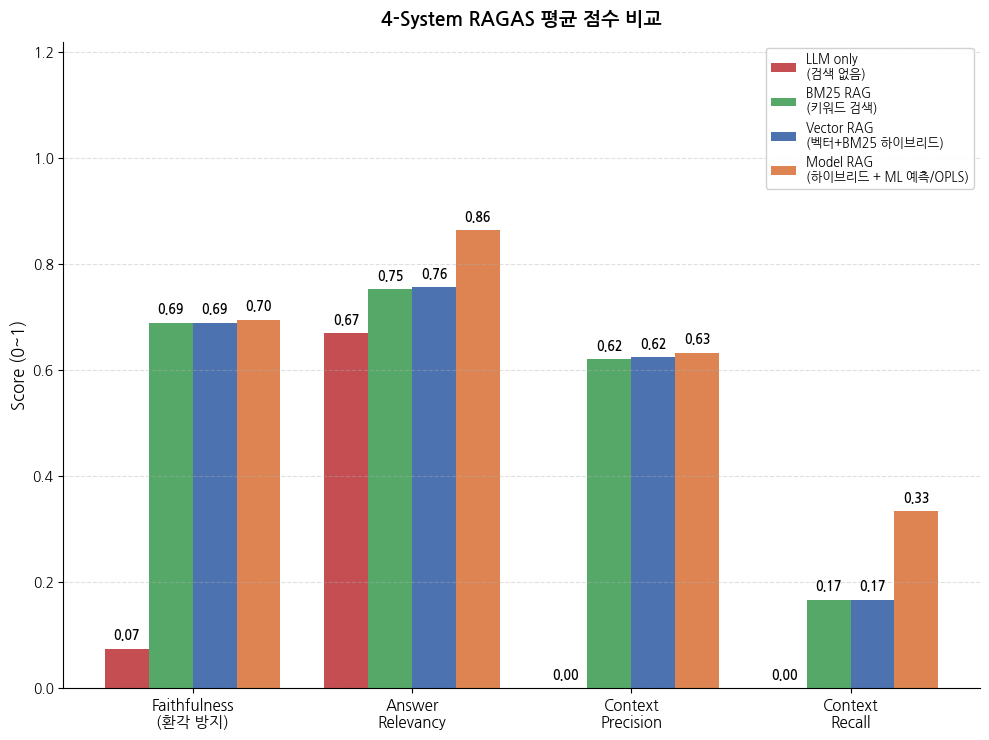


===== 4-System Baseline 비교 결과 =====
                                  faithfulness  answer_relevancy  context_precision  context_recall
system                                                                                             
LLM only / (검색 없음)                      0.0741            0.6695             0.0000          0.0000
BM25 RAG / (키워드 검색)                     0.6897            0.7532             0.6204          0.1667
Vector RAG / (벡터+BM25 하이브리드)            0.6894            0.7568             0.6245          0.1667
Model RAG / (하이브리드 + ML 예측/OPLS)        0.6954            0.8640             0.6326          0.3333


In [36]:
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd

# Colab 한글 폰트 설치
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
fm.fontManager.__init__()
matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

metric_cols   = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
metric_labels = ["Faithfulness\n(환각 방지)", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]

colors = {
    "llm_only"  : "#C44E52",
    "bm25_rag"  : "#55A868",
    "vector_rag": "#4C72B0",
    "model_rag" : "#DD8452",
}
labels = {
    "llm_only"  : "LLM only\n(검색 없음)",
    "bm25_rag"  : "BM25 RAG\n(키워드 검색)",
    "vector_rag": "Vector RAG\n(벡터+BM25 하이브리드)",
    "model_rag" : "Model RAG\n(하이브리드 + ML 예측/OPLS)",
}

systems = [s for s in ["llm_only", "bm25_rag", "vector_rag", "model_rag"] if s in system_results]
n_sys   = len(systems)

# ── 시스템별 평균 점수 바 차트 (4:3 논문용) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7.5))   # 4:3 비율
x      = list(range(len(metric_cols)))
width  = 0.8 / n_sys

for i, sys in enumerate(systems):
    vals   = [system_results[sys][m].dropna().mean() for m in metric_cols]
    offset = (i - n_sys / 2 + 0.5) * width
    bars   = ax.bar(
        [xi + offset for xi in x], vals,
        width=width, label=labels.get(sys, sys), color=colors.get(sys, "#888888"),
    )
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.22)
ax.set_ylabel("Score (0~1)", fontsize=12)
ax.set_title("4-System RAGAS 평균 점수 비교", fontsize=14, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=9, ncol=1, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("ragas_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()

# ── 요약표 ────────────────────────────────────────────────────────────────────
summary_rows = []
for sys in systems:
    row = {m: system_results[sys][m].dropna().mean().round(4) for m in metric_cols}
    row["system"] = labels.get(sys, sys).replace("\n", " / ")
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("system")
print("\n===== 4-System Baseline 비교 결과 =====")
print(summary_df.to_string())

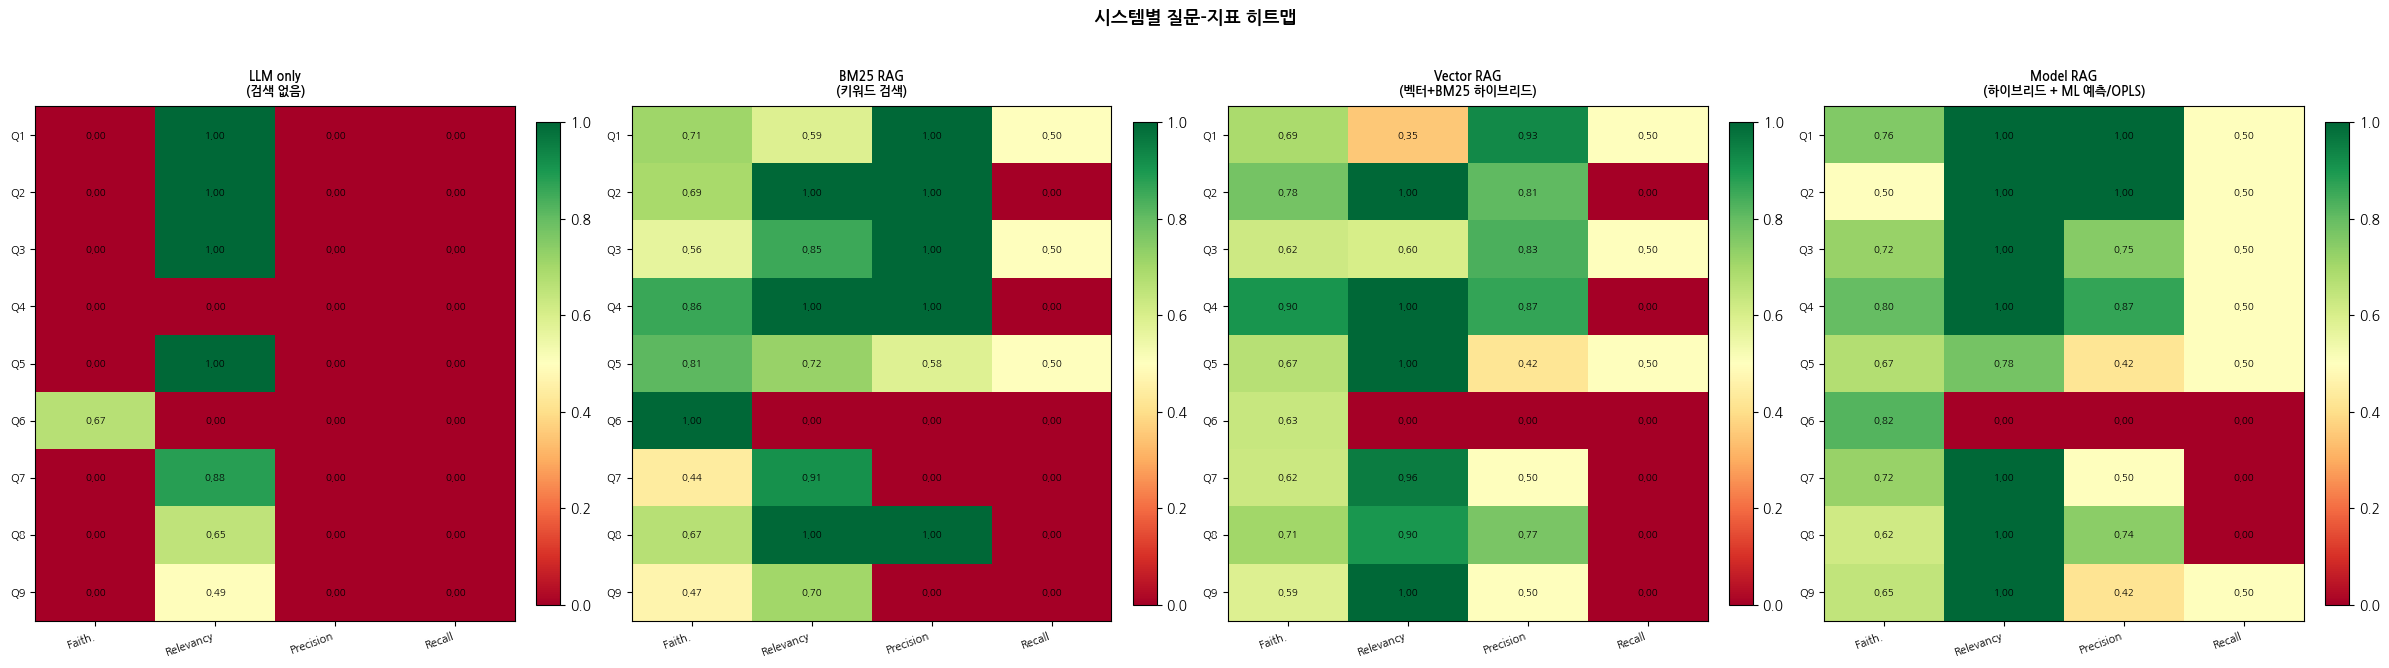

히트맵 저장: ragas_heatmap.png


In [37]:
# ── 시스템별 질문-지표 히트맵 (4개 나란히) ────────────────────────────────────
short_labels = ["Faith.", "Relevancy", "Precision", "Recall"]

fig, axes = plt.subplots(1, n_sys, figsize=(6 * n_sys, max(4, len(system_results[systems[0]]) * 0.5 + 2)))

for col_idx, sys in enumerate(systems):
    ax    = axes[col_idx]
    df    = system_results[sys]
    data  = df[metric_cols].values.astype(float)

    im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(metric_cols)))
    ax.set_xticklabels(short_labels, fontsize=8, rotation=20, ha="right")
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f"Q{i+1}" for i in range(len(df))], fontsize=8)
    ax.set_title(labels.get(sys, sys), fontsize=9, fontweight="bold", pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(len(df)):
        for j in range(len(metric_cols)):
            val = data[i, j]
            txt = f"{val:.2f}" if not np.isnan(val) else "-"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color="black")

plt.suptitle("시스템별 질문-지표 히트맵", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ragas_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("히트맵 저장: ragas_heatmap.png")